<a href="https://colab.research.google.com/github/imaniiz/CariSurg-Portfolio/blob/feat%2Fweek-5-refactor/Notebooks/Week5_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARISURG MedTech Pathways | Heathcare AI Programme | Week 5 Assignment
#**AI-Assisted Triage: Data Exploration**

---

##**About this Notebook**
This notebook explores the de-identified emergency department arrivals dataset: the Yale EMMLC triage extract. The goal of this notebook is to assess whether the dataset is suitable for AI-assisted triage modelling.

##**Research Question:**
Is this dataset good enough to build a triage prediction model and if so, with what caveats?

The data analysis focuses on:


*   Dataset structure and feature families
*   Missingness and data quality
*   Target variable balance
*   Clinical plausibility of vital signs
*   Demographic representation
*   Cheif complaint patterns
*   Early feature shortlist for Week 6 modelling

##**Notebook Sections**
Section 1: Data Loading and Environment Setup

Section 2: Feature Families

Section 3: Data Cleaning & Missingness Assessment

Section 4: Target Variable & Data Type Audit

Section 5: Vital Signs & Clinical Plausibility

Section 6: Outlier Detection

Section 7: Chief Complaints

Section 8: Demographics

Section 9: Data Quality Issues

Section 10: Conclusion











##**Section 1: Data Loading & Environment Setup**

The analysis uses the NumPy, Pandas and Matplotlib libraries for numerical operations, data manipulation and data visualisation respectively. The dataset is first loaded from Google Drive into a Pandas DataFrame.

Although the data has been de-identified, it is still treated as sensitive healthcare information and the raw CSV is excluded from version and is not committed to the GitHub repository.



In [109]:
# Environment Setup
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready · pandas 2.2.2


In [110]:
from pathlib import Path

CLEAN_PATH = Path("triage_cleaned_v1.csv")
RAW_PATH = Path('/content/drive/MyDrive/Carisurg Portfolio/CariSurg_Week5/yaleemmlc_admissionprediction_triage.csv')

df = pd.read_csv(RAW_PATH)
print(df.shape)

(55121, 226)


In [111]:
# Printing the first 5 rows of the data
df.head()


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Observations

The dataset contains **55,121 emergency department encounters** and **225 columns**. This confirms that the dataset is large enough for exploratory analysis and baseline modelling. However, the number of columns is high, so the features need to be grouped into clinical categories rather than reviewed one by one.

## **Section 2: Feature Families**

To make the dataset easier to interpret, the columns were grouped into families. This simplifies analysis by grouping related varaibles according to their clinical and modelling roles.

Main Families:

1.   Target - Emergency Severity Index (ESI) Triage level
2.   Vitals - Measurements taken at arrival
3. Demographics - Patient characteristics
4. Administrative Variabels - Arrival details
5. Leakage variables - Outcomes that happen after triage and are not used for prediction
6. Chief Complaints - Binary 0/1 indicators showing whether a complaint was recorded



In [112]:
# Printing information on dataset

print("Column types at a glance:")     # Column types
print(df.dtypes.value_counts(), "\n")  # No. of numeric vs text columns

# Separating the dataset into:
# Strctured columns: demographiuc, clinical, administrative and outcome variables
# Chief compliant(cc) flags: binary (0/1) indicators showing whether a patient presented
# with a particular compliant eg. chest pain
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

# Printing information on the structured columns of the dataset
df[structured].info()

# Printing the number of chief compliant flags
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}")

Column types at a glance:
float64    210
object      15
int64        1
Name: count, dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              55121 non-null  int64  
 1   dep_name                55121 non-null  object 
 2   esi                     55121 non-null  float64
 3   age                     55121 non-null  float64
 4   gender                  55121 non-null  object 
 5   ethnicity               55121 non-null  object 
 6   race                    55121 non-null  object 
 7   lang                    55121 non-null  object 
 8   religion                55121 non-null  object 
 9   maritalstatus           55121 non-null  object 
 10  employstatus            55121 non-null  object 
 11  insurance_status        55121 non-null  object 
 12  disposition             55121 non-null  objec

In [113]:
# Sorting dataset into feature familites

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent), 5 (least)

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Who the patient is (fairness-sensitive information)
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit - known only AFTER triage
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Keeping only the names that really exist in df
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # Sorting the chief compliant's columns by prefix
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

##**Section 3: Data Cleaning & Missingness Assessment**

Before analysing the dataset, a series of data cleaning steps are performed to improve data quality while preserving clinically meaningful information. The aim is to remove obvious errors and ensure the dataset is suitable for exploratory analysis and subsequent model development.

The cleaning pipeline follows five main steps:
1. Remove records with missing Emergency Severity Index (ESI) labels
2. Convert vital signs and age to numeric data types
3. Replace physiologically impossible values with missing values ('NaN')
4. Impute missing values using clinically appropriate methods
5. Ensure the target variable ('esi') is stored as an integer between 1 and 5



###Clinical Reference Ranges

Before assessing data quality, it is important to understand what each vital sign represents clinically. During emergency department triage, these measurements provide an objective assessment of a patient's physiological condition and help clinicians determine the urgency of treatment.

The dataset record the following vital signs:

| Dataset Feature | Abbreviation | Clinical Meaning | Plausible Range | Unit |
|-----------------|--------------|------------------|-----------------|------|
| `age` | Age | Patient age | 0–120 | years |
| `esi` | ESI | Emergency Severity Index | 1–5 | level |
| `triage_vital_hr` | HR | Heart Rate | 20–250 | bpm |
| `triage_vital_sbp` | SBP | Systolic Blood Pressure | 50–300 | mmHg |
| `triage_vital_dbp` | DBP | Diastolic Blood Pressure | 20–200 | mmHg |
| `triage_vital_rr` | RR | Respiratory Rate | 4–60 | breaths/min |
| `triage_vital_o2` | SpO₂ | Oxygen Saturation | 50–100 | % |
| `triage_vital_temp` | Temp | Body Temperature* | 86–110 | °F |
| `triage_glucose` | Glucose | Blood Glucose Level | 20–800 | mg/dL |

In [114]:
# Reference ranges for general adult triage

# Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

###Clinical Question 1:
Are there systematic patterns of missing data within the structured clinical variables that could reduce dataset quality or introduce bias into a prediction model?

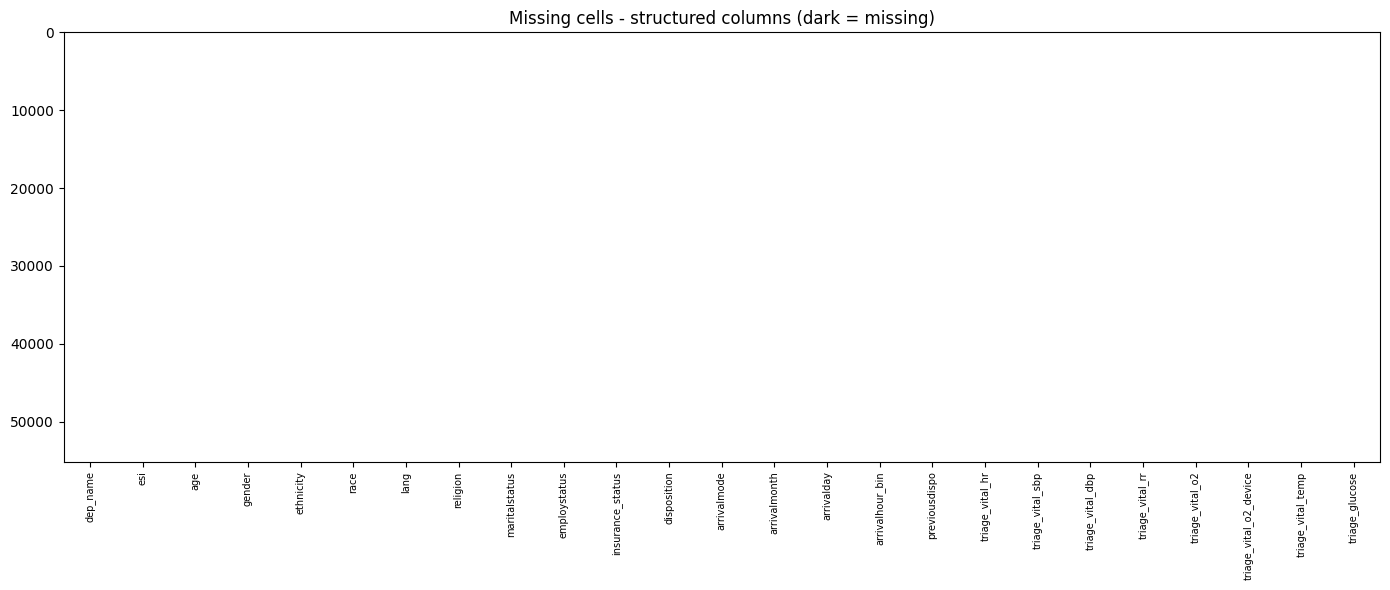

In [115]:
# Assignment Plot 1: Missing Cells - Structured column before cleaning
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

fig, ax = plt.subplots(figsize =(14,6))
ax.imshow(src[structured].isna().values, aspect ="auto", cmap="gray_r")
ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)
ax.set_title("Missing cells - structured columns (dark = missing)")
plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()


In [116]:
import os
def clean_triage(raw):
    """Week-5 cleaning pipeline. Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [117]:
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")

raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True);

structured = [c for c in df.columns if not c.startswith("cc")]
cc_flags = [c for c in df.columns if c.startswith("cc")]

Rebuilt from raw via clean_triage()


###Missingness Assessment

Missing data is a common challenge in clinical datasets and can influence both model performance and clinical intepretation. Before proceeding with exploratory analysis, the proportion of missing values is calculated for each structured feature to identify variables that may require additional cleaning or interpretation.

To complement the numerical summary, the **Missingno** python library is used to generate a missingness map which provides a visual representation of where missing values occur in the dataset.

In [12]:
!pip install missingno -q

In [118]:
# Determining the percentage of missing per structured column using .isna()
# worst first, gaps only

#Re-calculated the structured column based on the current clean df
structured = [c for c in df.columns if not c.startswith("cc_")]

# Determining fraction of missing values per column
missing_fraction = df[structured].isna().mean()

# Turning fraction into a percentage and sorting in ascending order
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# Showing only the number columns with gap or missing data
missing_percent[missing_percent > 0]

,0


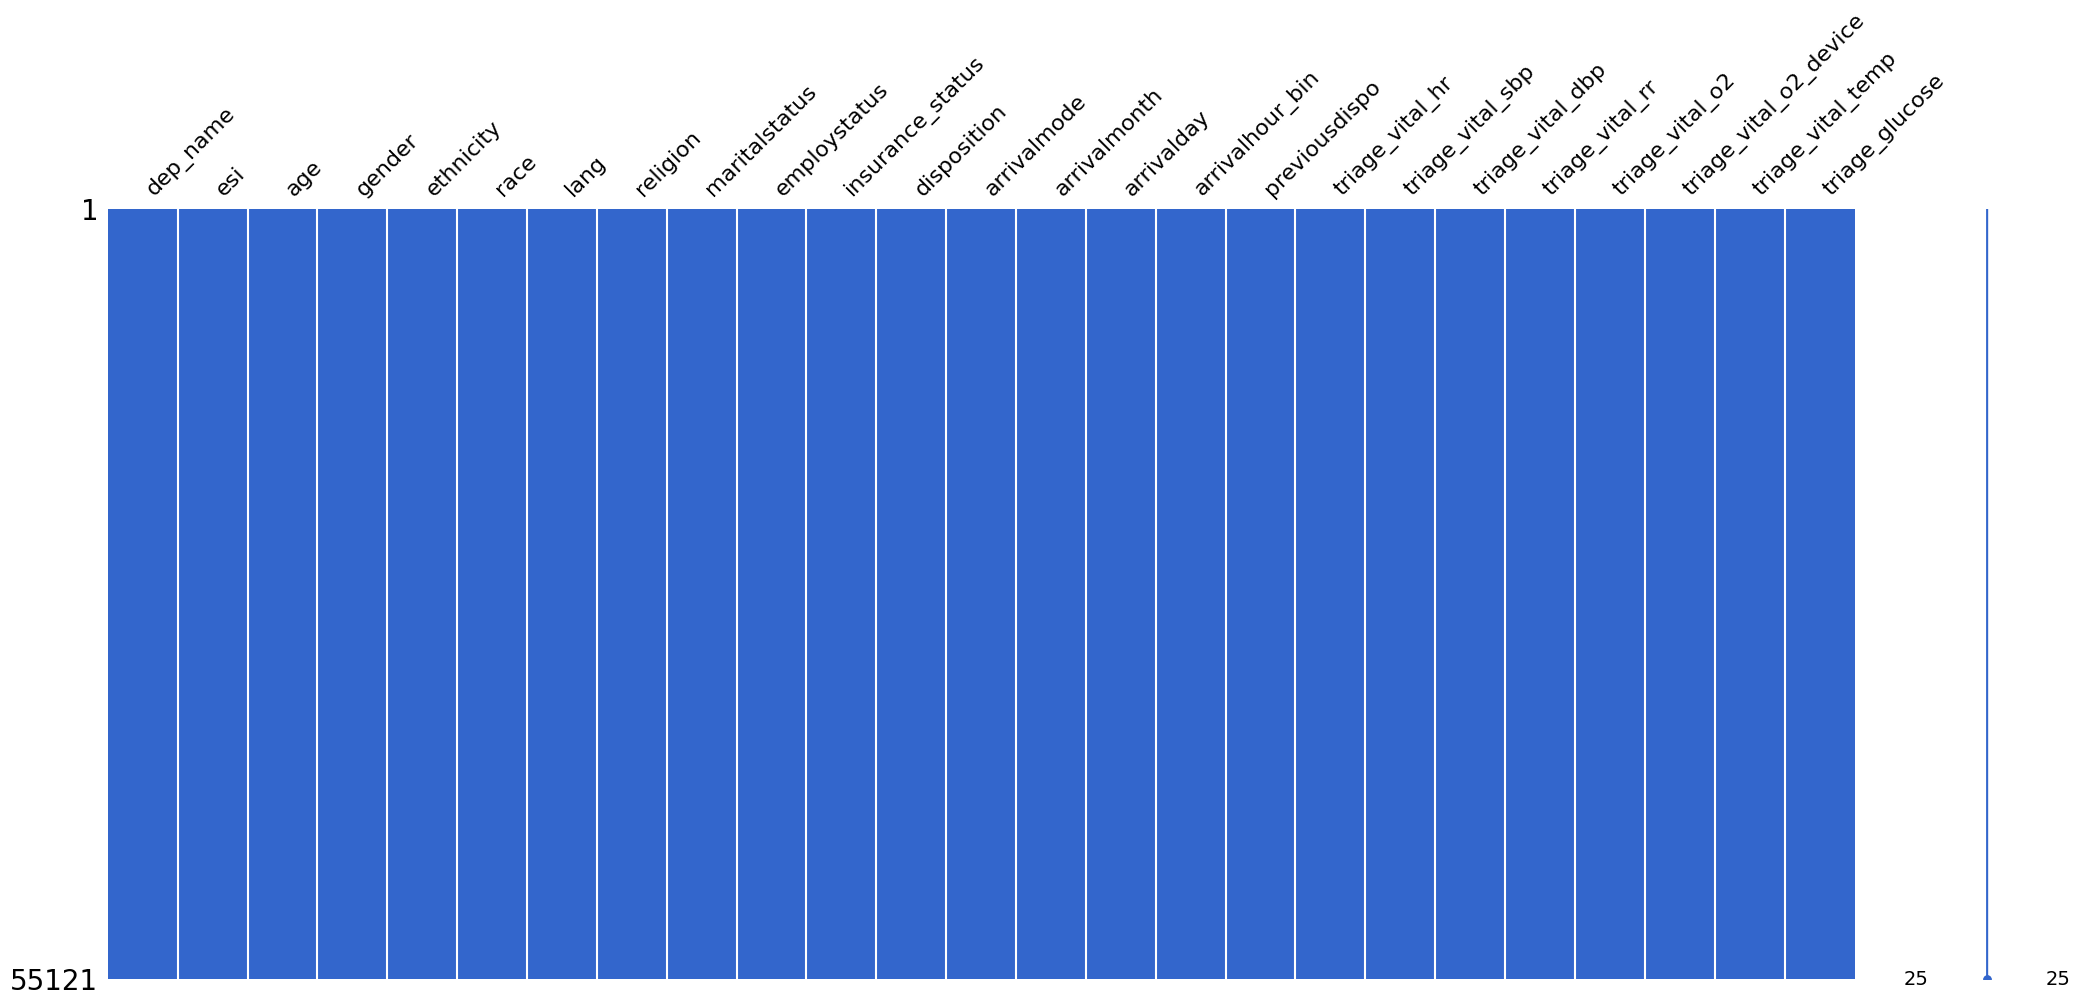

In [119]:
import os

# Re-calculate structured based on the current df columns
structured = [c for c in df.columns if not c.startswith("cc_")]

# Missingness map of the structured block (a 226-col map is unreadable)
try:
    import missingno as msno
    msno.matrix(df[structured], color=(0.2,0.4,0.8)); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

###Observations

The missingness maps shows that the structured clinical variables are entirely complete with a missing data percentage of 0%. A complete dataset eliminates bias due to missing variables making it stronger for use in a baseline triage prediction model.

## **Section 4: Target Variable and Data Type Audit**

The target variable is 'esi' which represents the emergency severity index. Lower ESI values mean higher urgency with ESI 1 being the most urgeny and ESI 5 meaning the least.


A data type audit checks whether each column is stored in the correct format. This matters because numeric clinical variables such as heart rate or blood pressure must be treated as numbers while categories such as gender or race should remain categorical.



In [120]:
# Data types audit and target sanity
print(df[structured].dtypes)

dep_name                   object
esi                         int64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object


In [121]:
esi_summary = pd.DataFrame({
    "Count": df[TARGET].value_counts().sort_index(),
    "Percentage (%)": (
        df[TARGET].value_counts(normalize=True).sort_index()*100
    ).round(1)
})
esi_summary

,Count,Percentage (%)
esi,,
1,77,0.1
2,17924,32.5
3,27010,49.0
4,8896,16.1
5,1214,2.2


###Clinical Question 2:
Is the Emergency Severity Index (ESI) target variable balanced across severity levels?

Text(0, 0.5, 'Number of Patient Encounters')

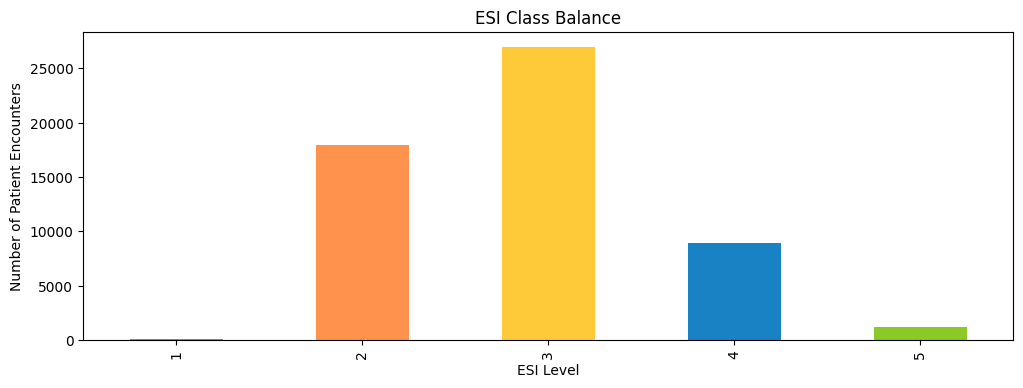

In [122]:
fig, ax = plt.subplots(figsize=(12,4))

colours = ["#FF595E", "#FF924C", "#FFCA3A", "#1982C4", "#8AC926"]

df[TARGET].value_counts().sort_index().plot.bar(ax=ax, color=colours)
ax.set_title("ESI Class Balance")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Number of Patient Encounters")



###Observations

The ESI distribution showed that the dataset is dominated by ESI 2 and ESI 3 cases which made up 32.5% and 49% of the dataset respectively. This distribution is plausible because it is consistent with a typical emergency department population. The data audit revealed that vital sign columns are stored as numeric vales, while demographic and administrative variables are stored as objects. This structure is appropriate for exploration, although categorical variables will require encoding before they can be used in machine learning models.

##**Section 5: Vital Signs & Clinican Plausibility**

Vital signs are clinically important because they reflect the patient's physiological state at arrival and is essential for determining acuity and ESI. The valid clinical ranges for each vital signs was further discussed in section 2 above. The distribution of the vital signs in the dataset should be observed at a glance to determine if they are clinically plausible.

The main vital signs present in the dataset are:

1. Heart Rate
2. Systolic Blood Pressure
3. Diastolic Blood Pressure
4. Respiratory Rate
5. Oxygen Saturation
6. Body Temperature
7. Blood Glucose Level

In [123]:
# Vital signs — quick statistical summary
vitals = [
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_temp",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_o2"
]

df[vitals].describe().T

,count,mean,std,min,25%,50%,75%,max
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0
triage_vital_rr,55121.0,17.838753,2.028622,8.0,16.0,18.0,18.0,60.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0


In [124]:
# Making a numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# VITALS vs ESI
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

Vital vs ESI:
triage_vital_rr     -0.097
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64


###Clinical Question 3:

Do the recorded vital signs fall within clinically plausible physiological ranges expected for emergency department patients?

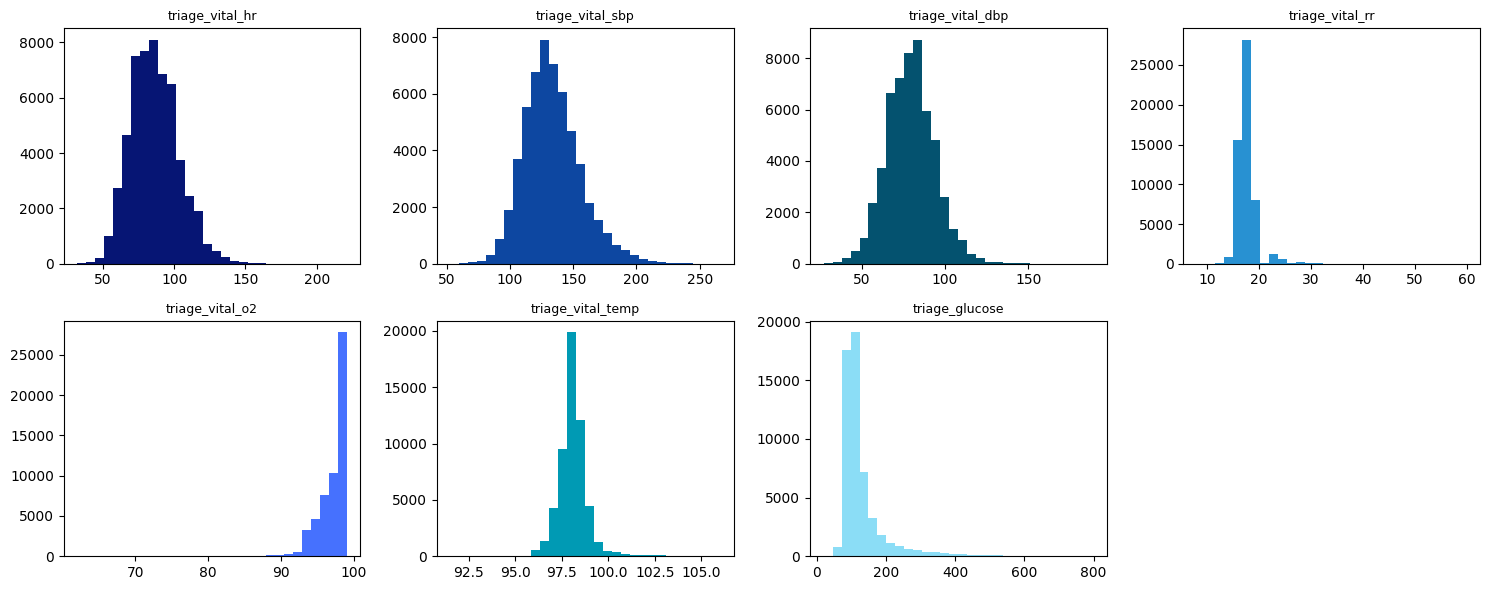

In [125]:
# Draw a histogram for each vital. (The instructor version also adds an ESI bar.)
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

colours = ["#061574","#0D47A1","#04526F", "#2891D2", "#4671FE", "#009AB4","#8BDDF6"]

# Cleaning df[col] by converting to numeric, removing errors and NaNs
for panel, col, color in zip(panels, vitals,colours):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color=color)
    panel.set_title(col, fontsize=9)
    pass

for panel in panels[len(vitals):]:
    panel.axis("off")



plt.tight_layout(); plt.show()

###Observations:


The histograms indicate that the recorded vital signs generally fall within clinically realistic ranges and displayed distributions that are consistent with an expected emergency department populations.

Heart rate, systolic blood pressure and diastolic blood pressure are centered around normal adult values, while oxygen saturation and body temperatureare tightly clustered within their expected physiological ranges.



###Clinical Question 4:

Which physiological measurements show the greatest separation between ESI classes and are therefore likely to be more informative predictors of triage severity?

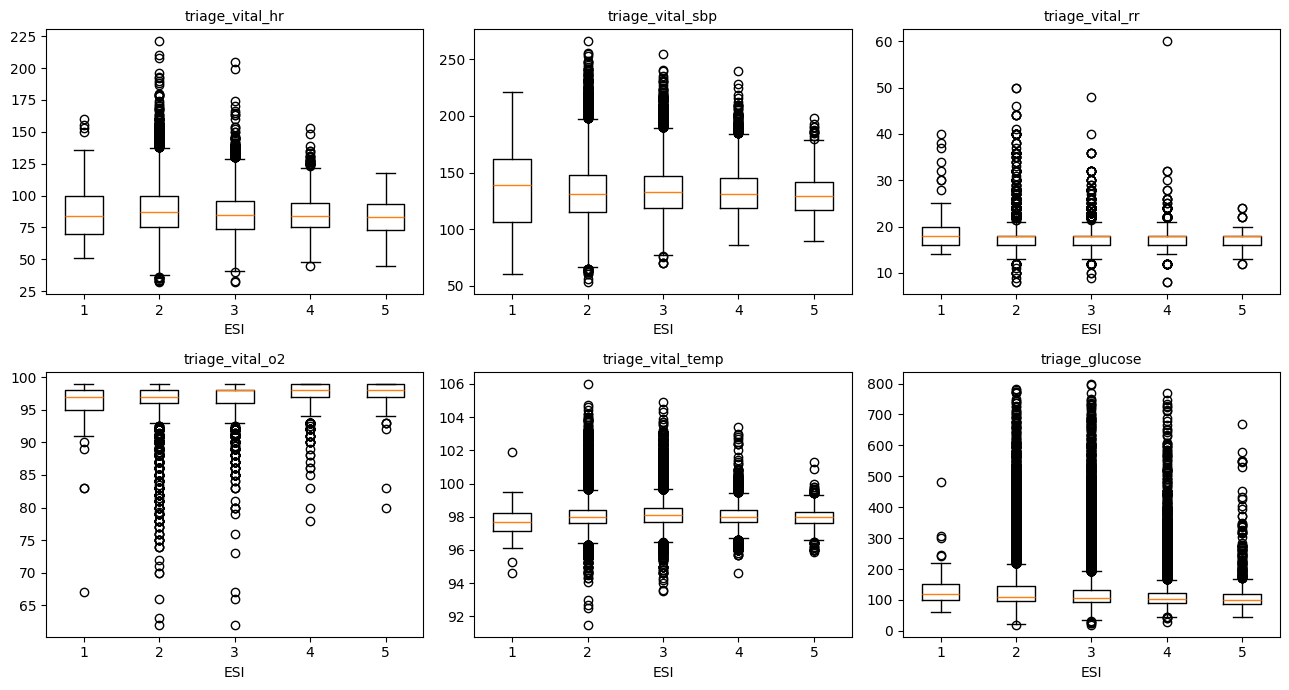

In [126]:
# Assignment Plot 5: Do vitals separate the ESI classes?

vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13,7))

for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]

    # Draw a boxplot with one box per ESI level, labelled by level
    panel.boxplot(groups, tick_labels=esi_levels)

    panel.set_title(col, fontsize=10)
    panel.set_xlabel("ESI")

plt.tight_layout(); plt.savefig("figs/05_vitals_by_esi.png", dpi=110); plt.show()

###Clinical Question 5:

Which vital signs demonstrate the strongest statistical relationship with the ESI?

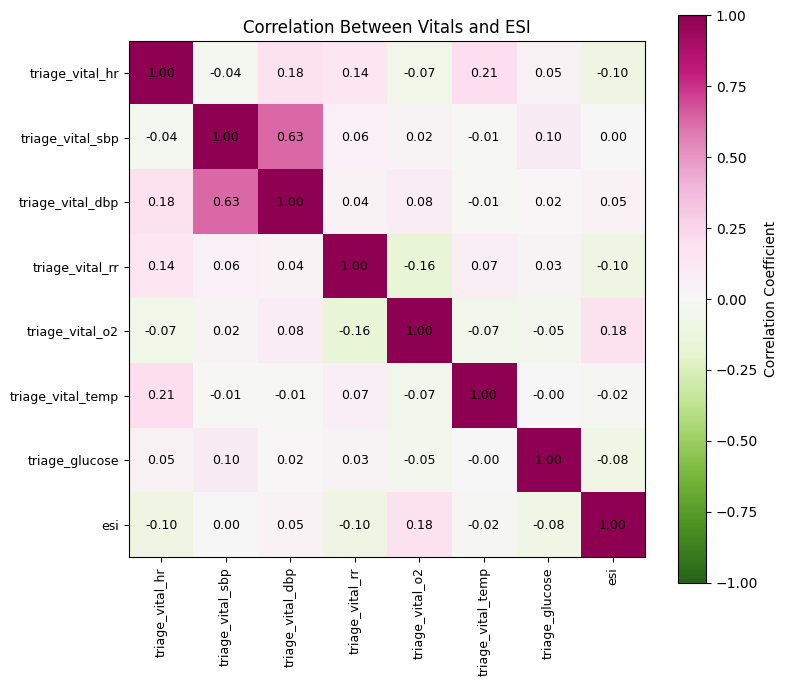

(None, None, None)

In [127]:
# Assignment Plot 6 - Correlation between Vitals & ESI (Complaint<->Acuity)
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr,cmap="PiYG_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=9)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=9)

for i in range(len(cols)):
  for j in range(len(cols)):
    ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlation Coefficient")
ax.set_title("Correlation Between Vitals and ESI")


plt.tight_layout(), plt.savefig("figs/06_correlation.png", dpi=110), plt.show()


Based on the correlation coefficients and boxplots, **oxygen saturation (SpO2)** shows the strongest association between ESI classes, showing lower oxygen levels among higher-acuity patients.

In contrast, **diastolic blood pressure (DBP)** demonstrates the weakest relationship with ESI, suggesting it contributes relatively little to distinguishing triage severity on its own.



## **Section 6: Outlier Detection**

Outliers in the dataset were assessed in two ways:

1. Statistical outliers - Values outside the 1.5 x IQR range
2. Clinically impossible values - Values outside broad physiological limits

This disntinction is important because a statistical outlier may still be clinically real, while clinically impossible values are likely to be data errors.

In [128]:
# Determining outliers
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only

    # STATISTICAL OUTLIERS (the 1.5 x IQR "fence")
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # CLINICALLY IMPOSSIBLE (outside the wide plausible bounds)
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2362,0
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5648,0


###Observations

The IQR analysis identified statistical outliers across all vital signs, with **blood glucose** containing the greatest number of observations outside the 1.5 x IQR limits, followed by **body temperature**. These values are statistically unusual but not incorrect, as emergency department patients often present with abnormal physiological measurements.

In addition, no clinically impossible values were detected using the predefined physiological limits, which indicates that the observations lie within clinically plausible ranges.

## **Section 7: Chief Complaints**

Chief compaints are important because they capture the patient's reasons for attending the emergency department. These variables may be highly predictive of triage level because some complaints are associated with higher acuity.



In [135]:
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}")


Chief-complaint flags (cc_*): 200


In [136]:
pd.DataFrame({"Chief Complaint": cc_flags})



,Chief Complaint
0,cc_abdominalcramping
1,cc_abdominaldistention
2,cc_abdominalpain
3,cc_abdominalpainpregnant
4,cc_abnormallab
...,...
195,cc_woundcheck
196,cc_woundinfection
197,cc_woundre-evaluation
198,cc_wristinjury


###Clinical Question 6:

Which presenting complaints occur most frequently in the emergency department?

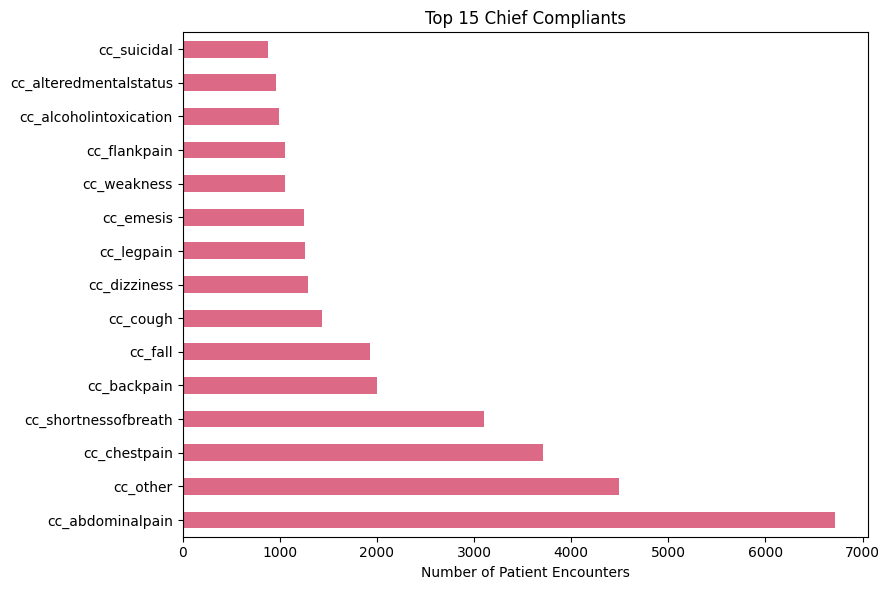

In [137]:
# Assignment Plot 4: Top Chief Complaints

cc_count = df[fam["chief_complaints"]].sum()
top_cc = cc_count.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9,6))

top_cc[::1].plot.barh(ax=ax, color="#DC6986")
ax.set_title("Top 15 Chief Compliants")
ax.set_xlabel("Number of Patient Encounters")

plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()


Determining the relationship with ESI and chief compliants is also necessary. Since lower ESI means higher urgency, a negative correlation means the feature is associated with higher acuity. It is important to note that these correlations are early signals and should not be interpreted as causation of the ESI level.

In [138]:
# CHIEF COMPLAINTS vs ESI (they are already 0/1 numbers)
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\n Chief Complaints vs ESI:")
print(cc_corr.head(8).round(3))



 Chief Complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


###Clinical Question 7:

Which chief complaints demonstrate the strongest statistical relationship with the ESI?

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


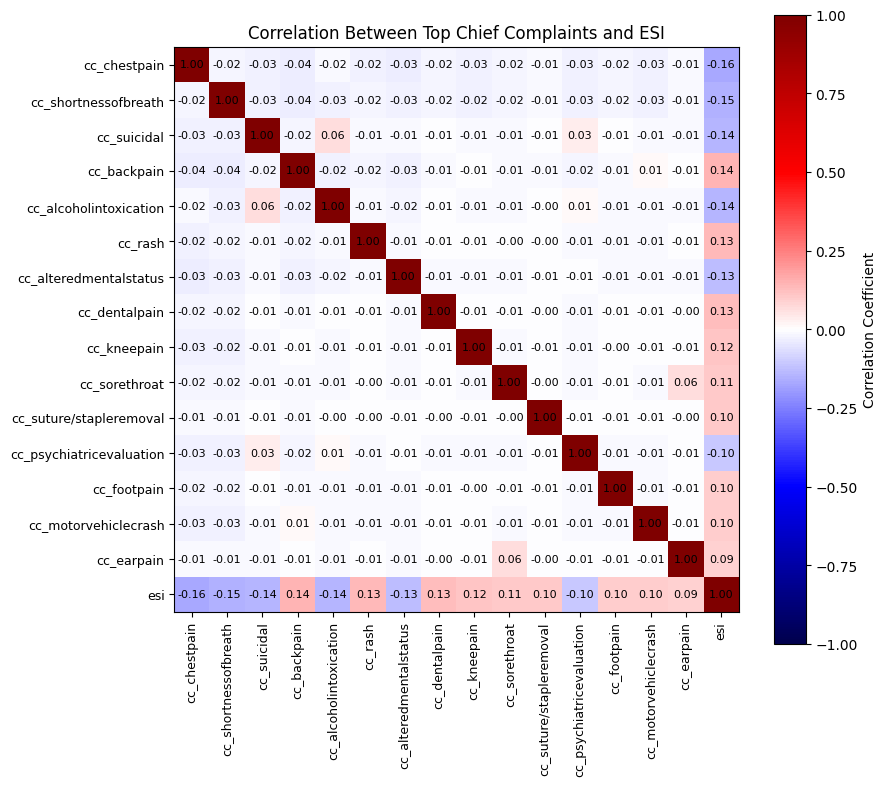

In [149]:
# Correlation between Chief Complaints & ESI

# Correlate every cc_ flag with ESI, drop any NaNs (complaints with zero variance)
cc_corr_all = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna()

# Take the top 15 complaints by strength of correlation (positive or negative)
top_cc = cc_corr_all.reindex(cc_corr_all.abs().sort_values(ascending=False).index).head(15)

# Building a correlation map: top complaints + ESI itself
cols_cc = list(top_cc.index) + [TARGET]
corr_cc = df[cols_cc].corr()

fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(corr_cc, cmap="seismic", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols_cc)))
ax.set_xticklabels(cols_cc, rotation=90, fontsize=9)
ax.set_yticks(range(len(cols_cc)))
ax.set_yticklabels(cols_cc, fontsize=9)

for i in range(len(cols_cc)):
    for j in range(len(cols_cc)):
        ax.text(j, i, f"{corr_cc.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation Coefficient")
ax.set_title("Correlation Between Top Chief Complaints and ESI")

plt.tight_layout(); plt.savefig("figs/07_cc_correlation.png", dpi=110); plt.show()

###Clinical Question 8:

Do patients presenting with chest pain tend to receive more urgent ESI classification, as would be expected clinically?

In [139]:
# Chest pain by ESI
chestpain_esi = pd.crosstab(
    df[TARGET],
    df["cc_chestpain"],
    normalize="index"
) * 100

print(chestpain_esi.round(1))

cc_chestpain   0.0   1.0  2.0
esi                          
1             94.8   5.2  0.0
2             87.8  12.2  0.0
3             94.5   5.5  0.0
4             99.6   0.4  0.0
5             99.9   0.1  0.0


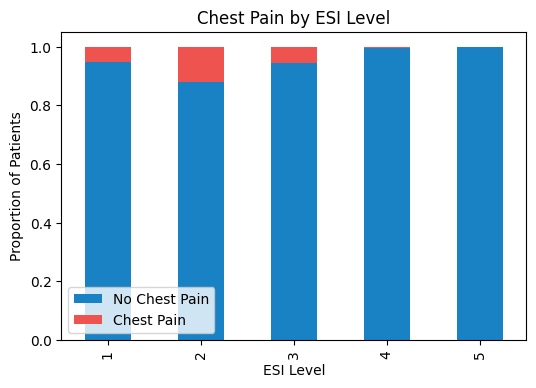

In [140]:
pd.crosstab(
    df[TARGET],
    df["cc_chestpain"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(6,4),
    color=["#1982C4","#EF5350"]
)

plt.title("Chest Pain by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Proportion of Patients")
plt.legend(["No Chest Pain","Chest Pain"])
plt.show()

###Observations

The analysis determined that there are 200 chief compliants where some including such as chest pain, shortness of breath, suicidal ideation, alcohol intoxication and altered mental status, show stronger relationships with higher acuity. This is clinically sensible because these presentations can indicate life-threatening or urgent conditions.

## **Section 8: Demographics**

Race and ethnicity were explored as a fairness check, not as simple predictors to rely on. If one demographic dominates the dataset, a model may perform better for that group and worse for underrepresented groups. This is especially important because the dataset comes from a US context, so its demogrpahic distribution may not transfer directly to a Caribbean emergency department.

In [141]:
# Gender
for c in ["gender"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

gender -> {'Female': 31744, 'Male': 23377}


In [142]:
# Demographics
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


###Clinical Question 9:

What age groups are represented within the dataset and is the patient population representative of an adult emergency department?

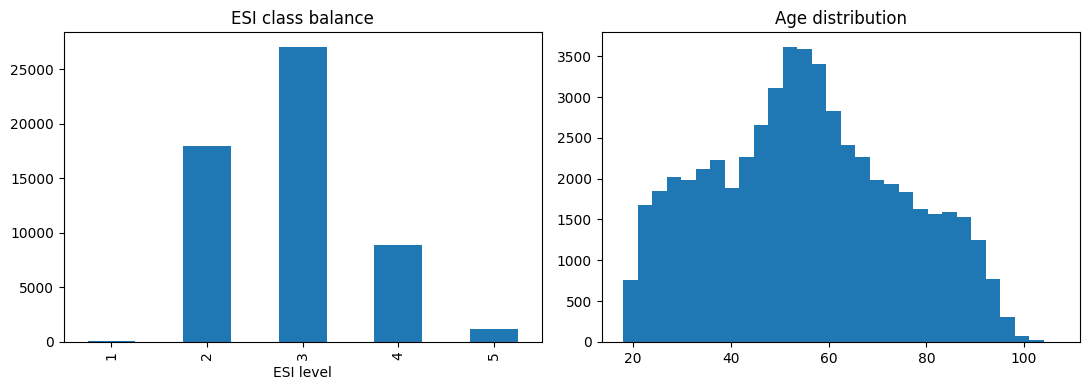

In [143]:
# Assignment Plot 2: ESI Balance & Age Distribution
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# ESI classes
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0])
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI level")

# Age histogram
ax[1].hist(df["age"], bins=30)
ax[1].set_title("Age distribution")

plt.tight_layout(); plt.savefig("figs/02_esi_age.png", dpi=110); plt.show()

###Clinical Question 10:

Does the dataset contain a diverse patient population, or are someracial and ethnic groups substantially underrepresented?

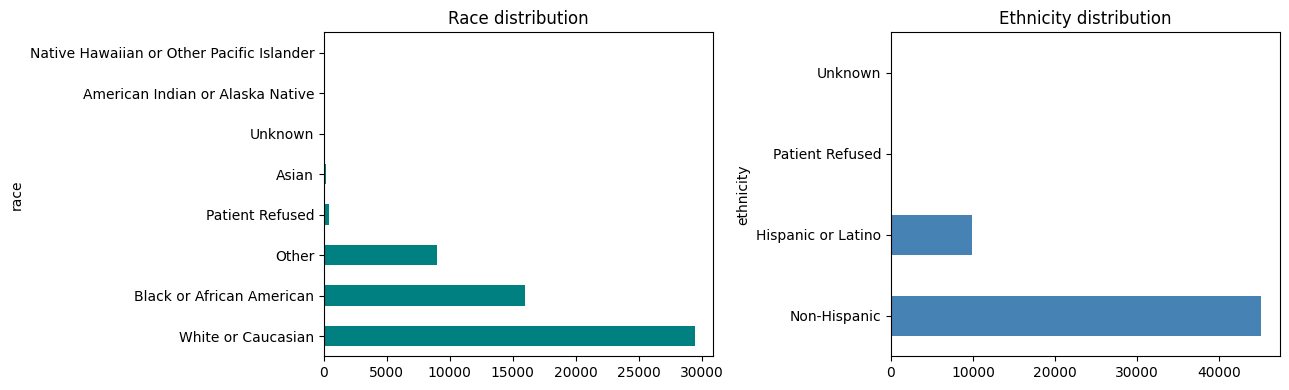

In [144]:
# Assignment Plot 3: Ethnicity & Race Distribution

fig, ax = plt.subplots(1, 2, figsize=(13,4))

# Race as a horizontal bar chart
race_counts = df["race"].value_counts()
race_counts.plot.barh(ax=ax[0], color="teal")
ax[0].set_title("Race distribution")

# Ethnicity as a horizontal bar chart
ethnicity_counts = df["ethnicity"].value_counts()
ethnicity_counts.plot.barh(ax=ax[1], color="steelblue")
ax[1].set_title("Ethnicity distribution")
plt.tight_layout(); plt.savefig("figs/03_demographics.png", dpi=110); plt.show()

###Clinical Question 11:

Does the distribution of ESI levels differ across racial groups in a way that could indicate potential bias or warrant further fairness evaluation?



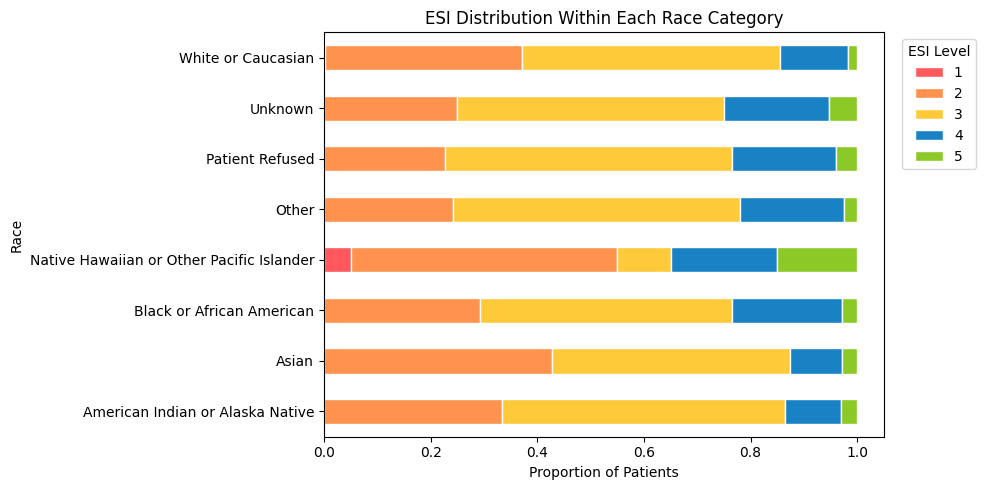

In [145]:
# ESI distribution within each race category
race_esi = pd.crosstab(
    df["race"],
    df[TARGET],
    normalize="index"
)

# Colours for ESI levels 1-5
colours = [
    "#FF595E",  # ESI 1 - Red
    "#FF924C",  # ESI 2 - Orange
    "#FFCA3A",  # ESI 3 - Yellow
    "#1982C4",  # ESI 4 - Blue
    "#8AC926"   # ESI 5 - Green
]

ax = race_esi.plot(
    kind="barh",
    stacked=True,
    figsize=(10,5),
    color=colours,
    edgecolor="white"
)

ax.set_title("ESI Distribution Within Each Race Category")
ax.set_xlabel("Proportion of Patients")
ax.set_ylabel("Race")
ax.legend(title="ESI Level", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

###Observations

The ESI distribution is broadly similar across most race categories, with **ESI Level 3** representing the largest proportion of encounters, followed by **ESI Levels 2 and 4**. This suggests that patients from different racial groups generally present with comparable levels of triage acuity within this dataset. One category, **Native Hawaiian or other Pacific Islander**, appears to have a relatively higher proportion of **ESI Levels 1 and 5** compared with other groups. Some race categories contain relatively few patients, therefore apparent differences should be interpreted cautiously.

From an equity perspective, a clinician would be concerned if one racial group consistently received markedly higher or lower ESI scores than other groups with similar clinical presentation. Such patterns could indicate potential bias in triage decisions, differences in healthcare access, or inconsistencies in documentation.

## **Section 9: Data Quality Issues**

Throughout the exploratory analysis, several data quality considerations were identified that may influence the development and performance of an AI-assisted triage model. While the dataset demonstrates strong overall completeness and clinically plausible vital sign distributions, a number of issues require appropriate handling during model development. The table below summarises the primary data quality identified, the variables

In [146]:
issues = [
    {
        "Issue": "Class imbalance",
        "Columns": "esi",
        "Evidence": "ESI Level 3 accounts for the largest proportion of encounters, while Levels 1 and 5 are comparatively rare.",
        "Action": "Use stratified sampling and appropriate evaluation metrics during modelling."
    },
    {
        "Issue": "Sparse chief complaint features",
        "Columns": "Chief complaint variables",
        "Evidence": "Most chief complaint indicators contain predominantly zero values.",
        "Action": "Evaluate feature importance before retaining all complaint variables."
    },
    {
        "Issue": "Extreme but clinically plausible values",
        "Columns": "Vital signs",
        "Evidence": "Many statistical outliers were identified, but no values fell outside the predefined physiological limits.",
        "Action": "Retain these observations, as they likely represent genuine emergency presentations."
    }
]

pd.DataFrame(issues)

,Issue,Columns,Evidence,Action
0,Class imbalance,esi,ESI Level 3 accounts for the largest proportio...,Use stratified sampling and appropriate evalua...
1,Sparse chief complaint features,Chief complaint variables,Most chief complaint indicators contain predom...,Evaluate feature importance before retaining a...
2,Extreme but clinically plausible values,Vital signs,"Many statistical outliers were identified, but...","Retain these observations, as they likely repr..."


##**Section 10: Conclusion**

Based on this exploration, the dataset appears feasible for building a Week 6 baseline triage model, but only with caveats.

The main strengths of the dataset are:

1. Large number of encounters
2. Complete target labels
3. Consistently recorded structure columns
4. Clinically meaningful chief compliant and vital sign features

The main concerns of the dataset are:

1. Class imbalance
2. Sparse chief compliant columns
3. Possible leakage variables
4. Limited transferability to a Caribbean emergency department

Therefore, the main verdict is: **proceed with baseline modelling, but report caveats clearly and evaluate performance carefully by ESI class and demographic subgroup**